<a href="https://colab.research.google.com/github/sashamontgomery/Neur-265/blob/main/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Sasha Montgomery
<i> NEUR 265 <i>

<b> March 6th, 2026


In [60]:
#import relevant modules
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [9]:
#import patch seq data

url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'


patch_seq = pd.read_csv(url)

Text(0, 0.5, 'Value Counts/# of Observations')

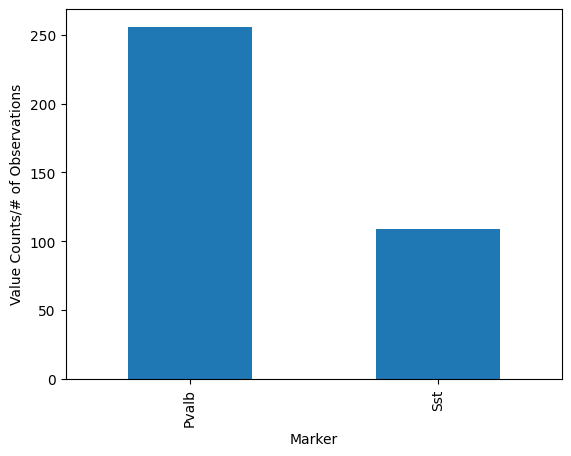

In [16]:
#plot patch seq as bar graph
patch_seq['Marker'].value_counts().plot(kind = 'bar')
plt.xlabel('Marker')
plt.ylabel('Value Counts/# of Observations')

Text(0, 0.5, 'Value Counts/# of Observations')

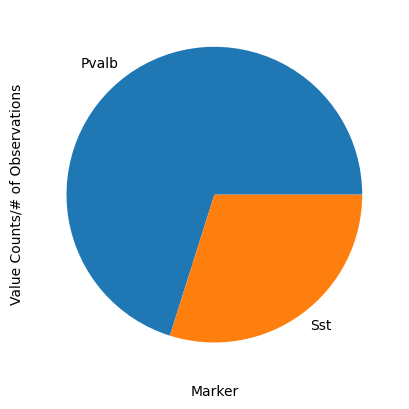

In [17]:
#plot patch seq as pie chart
#plot patch seq
patch_seq['Marker'].value_counts().plot(kind = 'pie')
plt.xlabel('Marker')
plt.ylabel('Value Counts/# of Observations')

Text(0.5, 0, 'ISI')

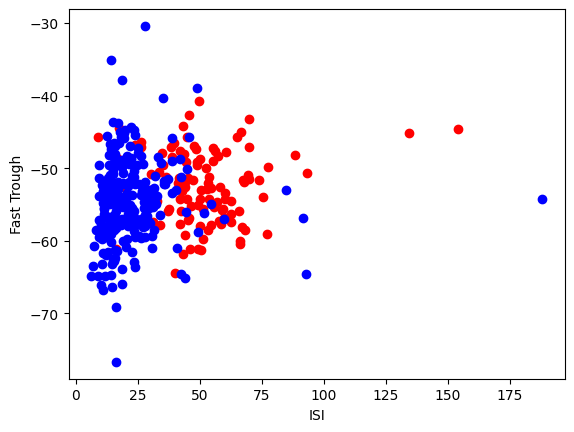

In [24]:
#Making scatterplot with for loop
patch_length = len(patch_seq)
for i in range(patch_length):
    x = patch_seq['ISI'].iloc[i]
    y = patch_seq['Fast_Trough'].iloc[i]
    marker = patch_seq['Marker'].iloc[i]
    if marker == 'Sst':
        plt.scatter(x, y, color='Red')
    if marker == 'Pvalb':
        plt.scatter(x, y, color='Blue')
plt.ylabel('Fast Trough')
plt.xlabel('ISI')

In [51]:
#defining a function for patchscatter
def patchScatter():
    patch_length = len(patch_seq)
    for i in range(patch_length):
      x = patch_seq['ISI'].iloc[i]
      y = patch_seq['Fast_Trough'].iloc[i]
      marker = patch_seq['Marker'].iloc[i]
      if marker == 'Sst':
          plt.scatter(x, y, color='Red')
      if marker == 'Pvalb':
          plt.scatter(x, y, color='Blue')
      plt.ylabel('Fast Trough')
      plt.xlabel('ISI')

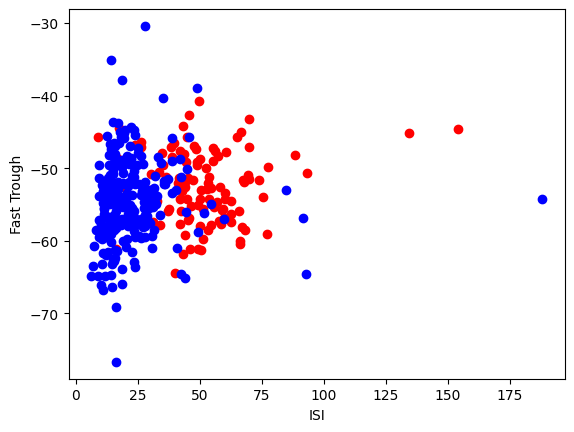

In [52]:
#checking patchscatter works right
patchScatter()

In [55]:
#getting mean sd and range
patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


The "Sst" neurons have a greater mean than the "Pvalb" neurons. This suggests that the Pvalb neuron group has a more negative undershoot following an action potential.

In [65]:
#checking fast trough skew
patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


The Pvalb neurons have a skewed distribution, while the Sst neurons do not have a skewed distribution.   

In [66]:
#checking ISI skew
patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


Both the Sst and the Pvalb neurons have a skewed distribution.



In [68]:
#t test with fast trough
sst_neurons = patch_seq [patch_seq['Marker']== 'Sst']
pvalb_neurons = patch_seq [patch_seq['Marker']== 'Pvalb']
stats.ttest_ind (sst_neurons['Fast_Trough'], pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

The undershoot voltage significantly differs between the two groups. I know this because the p value is <0.05

In [84]:
 #t test with ISI
sst_neurons = patch_seq [patch_seq['Marker']== 'Sst']
pvalb_neurons = patch_seq [patch_seq['Marker']== 'Pvalb']
sst1 = sst_neurons['ISI'].dropna()
pvalb1 = pvalb_neurons['ISI'].dropna()
stats.ttest_ind(sst1, pvalb1)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

The undershoot voltage does not differ significantly between the two ISI groups. I know this because the p value is greater that .05.